# CICIDS2017 - Exploratory Data Analysis
### Original 8 MachineLearningCSV Files
Run this notebook on Kaggle with the 8 original CSV files uploaded as a dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')

## 1. Load All 8 CSV Files

In [2]:
# Update this path to wherever your CSV files are
DATA_DIR = r'D:\Academic\ML\ModelTraining\dataset\MachineLearningCVE' # change if needed

csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print(f'Found {len(csv_files)} CSV files:')
for f in sorted(csv_files):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024 * 1024)
    print(f'  {f}  ({size_mb:.1f} MB)')

Found 8 CSV files:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (73.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (73.3 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv  (55.6 MB)
  Monday-WorkingHours.pcap_ISCX.csv  (168.7 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (79.3 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (49.6 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv  (128.8 MB)
  Wednesday-workingHours.pcap_ISCX.csv  (214.7 MB)


In [3]:
dfs = []
for f in sorted(csv_files):
    path = os.path.join(DATA_DIR, f)
    df_temp = pd.read_csv(path, low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()  # strip whitespace from column names
    df_temp['source_file'] = f
    print(f'{f}: {df_temp.shape[0]:,} rows, {df_temp.shape[1]} cols')
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(f'\nCombined shape: {df.shape}')

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows, 80 cols
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows, 80 cols
Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows, 80 cols
Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows, 80 cols
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows, 80 cols
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows, 80 cols
Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows, 80 cols
Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows, 80 cols

Combined shape: (2830743, 80)


## 2. Basic Dataset Overview

In [4]:
print('=== SHAPE ===')
print(df.shape)

print('\n=== COLUMN NAMES ===')
for i, col in enumerate(df.columns):
    print(f'  {i+1:2d}. {col}')

=== SHAPE ===
(2830743, 80)

=== COLUMN NAMES ===
   1. Destination Port
   2. Flow Duration
   3. Total Fwd Packets
   4. Total Backward Packets
   5. Total Length of Fwd Packets
   6. Total Length of Bwd Packets
   7. Fwd Packet Length Max
   8. Fwd Packet Length Min
   9. Fwd Packet Length Mean
  10. Fwd Packet Length Std
  11. Bwd Packet Length Max
  12. Bwd Packet Length Min
  13. Bwd Packet Length Mean
  14. Bwd Packet Length Std
  15. Flow Bytes/s
  16. Flow Packets/s
  17. Flow IAT Mean
  18. Flow IAT Std
  19. Flow IAT Max
  20. Flow IAT Min
  21. Fwd IAT Total
  22. Fwd IAT Mean
  23. Fwd IAT Std
  24. Fwd IAT Max
  25. Fwd IAT Min
  26. Bwd IAT Total
  27. Bwd IAT Mean
  28. Bwd IAT Std
  29. Bwd IAT Max
  30. Bwd IAT Min
  31. Fwd PSH Flags
  32. Bwd PSH Flags
  33. Fwd URG Flags
  34. Bwd URG Flags
  35. Fwd Header Length
  36. Bwd Header Length
  37. Fwd Packets/s
  38. Bwd Packets/s
  39. Min Packet Length
  40. Max Packet Length
  41. Packet Length Mean
  42. Packet Len

In [5]:
print('=== DTYPES ===')
print(df.dtypes.value_counts())
print()
df.dtypes

=== DTYPES ===
int64      54
float64    24
str         2
Name: count, dtype: int64



Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                              str
source_file                        str
Length: 80, dtype: object

## 3. Label Analysis (Raw Labels)

In [24]:
print(df.shape)
print(df.drop(columns=['Label','source_file']).describe().T[['mean','std','min','50%','max']].to_string())

(2826550, 81)
                                     mean           std           min           50%           max
Destination Port             8.071017e+03  1.828703e+04  0.000000e+00     80.000000  6.553500e+04
Flow Duration                1.480088e+07  3.367344e+07 -1.300000e+01  31298.000000  1.200000e+08
Total Fwd Packets            9.343754e+00  7.501852e+02  1.000000e+00      2.000000  2.197590e+05
Total Backward Packets       1.038484e+01  9.981019e+02  0.000000e+00      2.000000  2.919220e+05
Total Length of Fwd Packets  5.420261e+02  9.539266e+03  0.000000e+00     62.000000  1.290000e+07
Total Length of Bwd Packets  1.615528e+04  2.264718e+06  0.000000e+00    123.000000  6.554530e+08
Fwd Packet Length Max        2.075595e+02  7.150766e+02  0.000000e+00     37.000000  2.482000e+04
Fwd Packet Length Min        1.873979e+01  6.038020e+01  0.000000e+00      2.000000  2.325000e+03
Fwd Packet Length Mean       5.819441e+01  1.855259e+02  0.000000e+00     34.000000  4.672000e+03
Fwd Pa

In [6]:
# The label column in original files is ' Label' (with leading space) or 'Label'
label_col = ' Label' if ' Label' in df.columns else 'Label'
print(f'Label column: "{label_col}"')
print(f'\nUnique labels: {df[label_col].nunique()}')
print()

label_counts = df[label_col].value_counts()
print(label_counts)

Label column: "Label"

Unique labels: 15

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


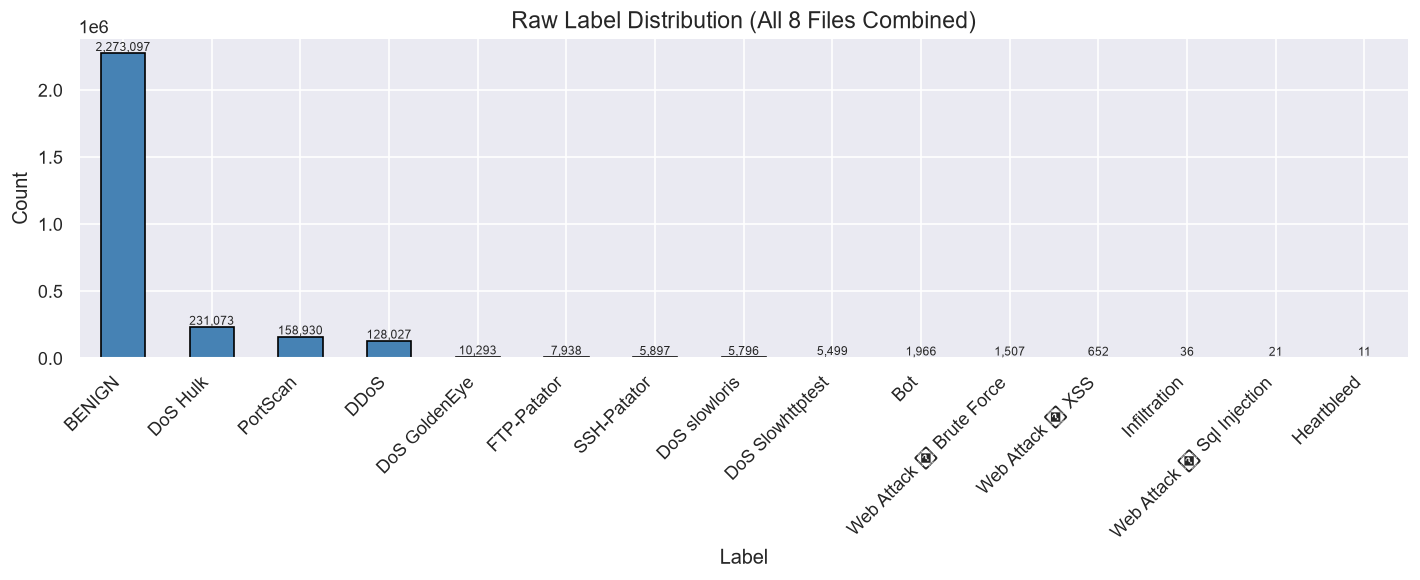

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
label_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Raw Label Distribution (All 8 Files Combined)', fontsize=14)
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('raw_label_distribution.png', bbox_inches='tight')
plt.show()

## 4. Label Grouping into 7 Classes
Normal + 6 Attack Types: DoS, DDoS, Brute Force, Port Scan, Bot, Web Attack

In [8]:
# Add this cell BEFORE the label_map to see exact bytes
web_labels = [l for l in df[label_col].unique() if 'Web' in l]
for l in web_labels:
    print(l.encode('utf-8'))

b'Web Attack \xef\xbf\xbd Brute Force'
b'Web Attack \xef\xbf\xbd XSS'
b'Web Attack \xef\xbf\xbd Sql Injection'


In [9]:
label_map = {
    'BENIGN': 'Normal Traffic',
    # DoS
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    # DDoS
    'DDoS': 'DDoS',
    # Brute Force
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    # Port Scan
    'PortScan': 'Port Scan',
    # Bot
    'Bot': None,
    'Web Attack \ufffd Brute Force': None,
    'Web Attack \ufffd XSS': None,
    'Web Attack \ufffd Sql Injection': None,
    # Drop these
    'Infiltration': None,
    'Heartbleed': None,
}

# Strip whitespace from labels first
df[label_col] = df[label_col].str.strip()

# Check if any labels aren't in the map
unmapped = set(df[label_col].unique()) - set(label_map.keys())
if unmapped:
    print(f'WARNING - unmapped labels found: {unmapped}')
    print('Update label_map above to handle these.')
else:
    print('All labels mapped successfully.')

All labels mapped successfully.


In [10]:
df['Attack Type'] = df[label_col].map(label_map)

# Drop rows where Attack Type is None (Infiltration, Heartbleed)
dropped = df['Attack Type'].isna().sum()
print(f'Dropping {dropped:,} rows (Infiltration + Heartbleed)')
df = df[df['Attack Type'].notna()].reset_index(drop=True)
print(f'Remaining rows: {df.shape[0]:,}')

print()
grouped_counts = df['Attack Type'].value_counts()
print(grouped_counts)

Dropping 4,193 rows (Infiltration + Heartbleed)
Remaining rows: 2,826,550

Attack Type
Normal Traffic    2273097
DoS                252661
Port Scan          158930
DDoS               128027
Brute Force         13835
Name: count, dtype: int64


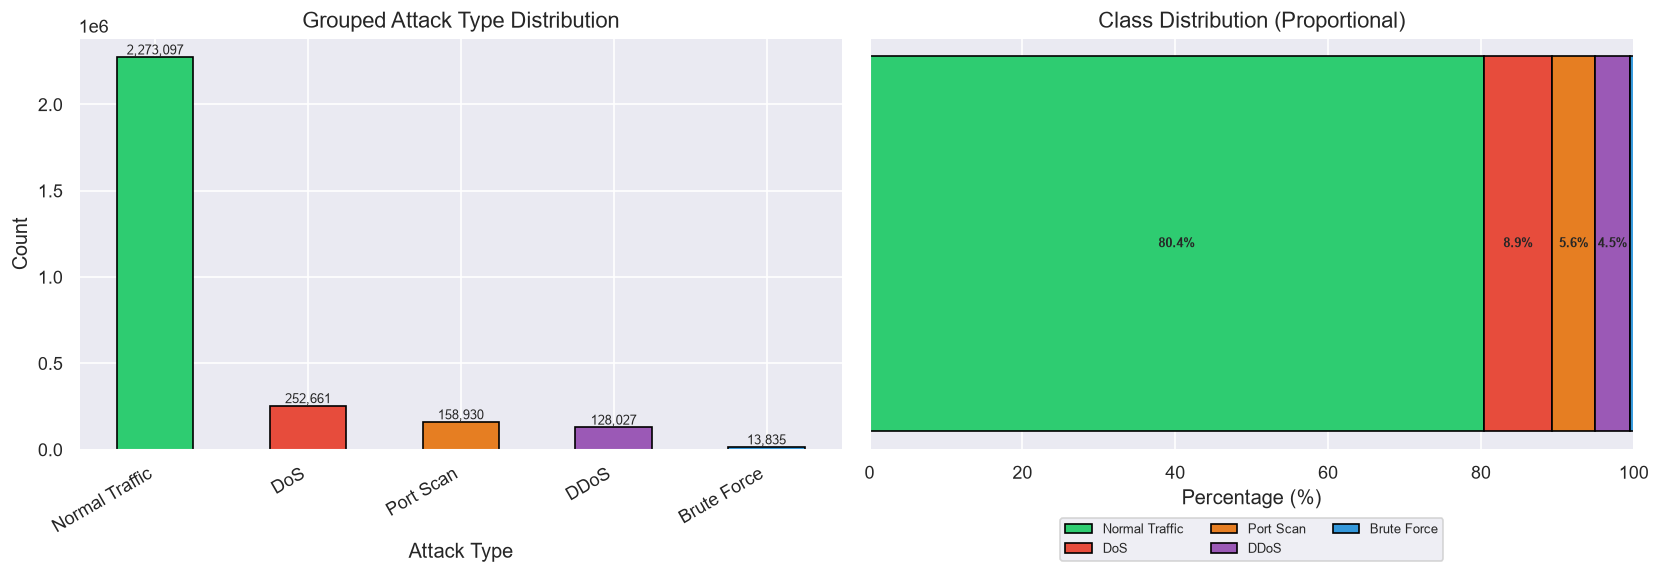

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c', '#e67e22', '#9b59b6', '#3498db', '#1abc9c', '#f39c12']
grouped_counts.plot(kind='bar', ax=axes[0], color=colors[:len(grouped_counts)], edgecolor='black')
axes[0].set_title('Grouped Attack Type Distribution', fontsize=13)
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=8)

# Stacked bar chart
total = grouped_counts.sum()
percentages = (grouped_counts / total * 100).values
labels_list = grouped_counts.index.tolist()

left = 0
for i, (pct, label) in enumerate(zip(percentages, labels_list)):
    axes[1].barh(0, pct, left=left, color=colors[i], edgecolor='black', height=0.5, label=label)
    if pct > 2:  # only annotate if wide enough to read
        axes[1].text(left + pct/2, 0, f'{pct:.1f}%', ha='center', va='center', fontsize=8, fontweight='bold')
    left += pct

axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Percentage (%)')
axes[1].set_yticks([])
axes[1].set_title('Class Distribution (Proportional)', fontsize=13)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)

plt.tight_layout()
plt.savefig('grouped_class_distribution.png', bbox_inches='tight')
plt.show()

## 5. Missing Values and Infinite Values

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns: {len(numeric_cols)}')

# Replace inf with NaN for analysis
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

missing = df[numeric_cols].isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'\nColumns with missing/inf values: {len(missing)}')
if len(missing) > 0:
    print(missing)

Numeric columns: 78

Columns with missing/inf values: 2
Flow Bytes/s      2857
Flow Packets/s    2857
dtype: int64


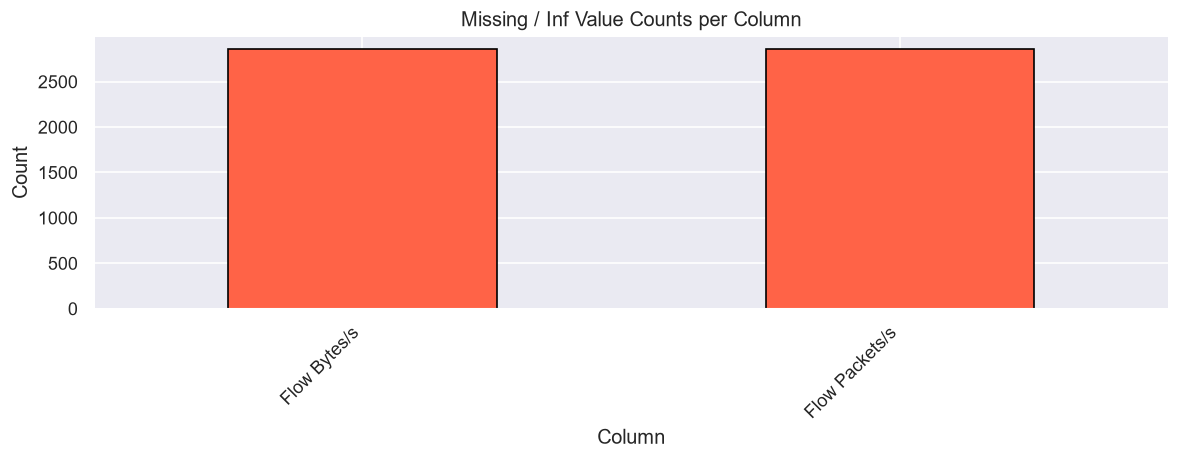

In [13]:
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
    ax.set_title('Missing / Inf Value Counts per Column')
    ax.set_xlabel('Column')
    ax.set_ylabel('Count')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('missing_values.png', bbox_inches='tight')
    plt.show()
else:
    print('No missing values after inf replacement.')

## 6. Feature Statistics

In [14]:
stats = df[numeric_cols].describe().T
stats.to_csv('feature_statistics_original.csv')
print('Feature statistics saved to feature_statistics_original.csv')
stats.head(20)

Feature statistics saved to feature_statistics_original.csv


,count,mean,std,min,25%,50%,75%,max
Destination Port,2826550.0,8.071017e+03,1.828703e+04,0.0,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,2826550.0,1.480088e+07,3.367344e+07,-13.0,155.000000,31298.000000,3.160457e+06,1.200000e+08
Total Fwd Packets,2826550.0,9.343754e+00,7.501852e+02,1.0,2.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,2826550.0,1.038484e+01,9.981019e+02,0.0,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2826550.0,5.420261e+02,9.539266e+03,0.0,12.000000,62.000000,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2826550.0,1.615528e+04,2.264718e+06,0.0,2.000000,123.000000,4.840000e+02,6.554530e+08
Fwd Packet Length Max,2826550.0,2.075595e+02,7.150766e+02,0.0,6.000000,37.000000,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2826550.0,1.873979e+01,6.038020e+01,0.0,0.000000,2.000000,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,2826550.0,5.819441e+01,1.855259e+02,0.0,6.000000,34.000000,5.000000e+01,4.672000e+03
Fwd Packet Length Std,2826550.0,6.890857e+01,2.809836e+02,0.0,0.000000,0.000000,2.616295e+01,7.125597e+03


## 7. Constant and Near-Constant Columns

In [15]:
unique_counts = df[numeric_cols].nunique()
constant_cols = unique_counts[unique_counts == 1].index.tolist()
print(f'Constant columns (1 unique value): {constant_cols}')

near_constant = unique_counts[unique_counts <= 2].index.tolist()
print(f'Near-constant columns (<=2 unique values): {near_constant}')

Constant columns (1 unique value): ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Near-constant columns (<=2 unique values): ['Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


## 8. Correlation Heatmap

In [16]:
# Use a sample for correlation (full dataset is too large)
sample = df[numeric_cols].dropna().sample(min(10000, len(df)), random_state=42)
corr = sample.corr()

# Find highly correlated pairs (>= 0.99)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= 0.99:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f'Highly correlated pairs (>= 0.99): {len(high_corr_pairs)}')
for a, b, v in high_corr_pairs:
    print(f'  {a}  <-->  {b}  : {v:.4f}')

Highly correlated pairs (>= 0.99): 27
  Flow Duration  <-->  Fwd IAT Total  : 0.9981
  Total Fwd Packets  <-->  Total Backward Packets  : 0.9909
  Total Fwd Packets  <-->  Fwd Header Length  : 0.9956
  Total Fwd Packets  <-->  Fwd Header Length.1  : 0.9956
  Total Fwd Packets  <-->  Subflow Fwd Packets  : 1.0000
  Total Fwd Packets  <-->  Subflow Bwd Packets  : 0.9909
  Total Backward Packets  <-->  Total Length of Bwd Packets  : 0.9948
  Total Backward Packets  <-->  Bwd Header Length  : 0.9931
  Total Backward Packets  <-->  Subflow Fwd Packets  : 0.9909
  Total Backward Packets  <-->  Subflow Bwd Packets  : 1.0000
  Total Backward Packets  <-->  Subflow Bwd Bytes  : 0.9948
  Total Length of Fwd Packets  <-->  Subflow Fwd Bytes  : 1.0000
  Total Length of Bwd Packets  <-->  Subflow Bwd Packets  : 0.9948
  Total Length of Bwd Packets  <-->  Subflow Bwd Bytes  : 1.0000
  Fwd Packet Length Mean  <-->  Avg Fwd Segment Size  : 1.0000
  Bwd Packet Length Mean  <-->  Avg Bwd Segment Size  :

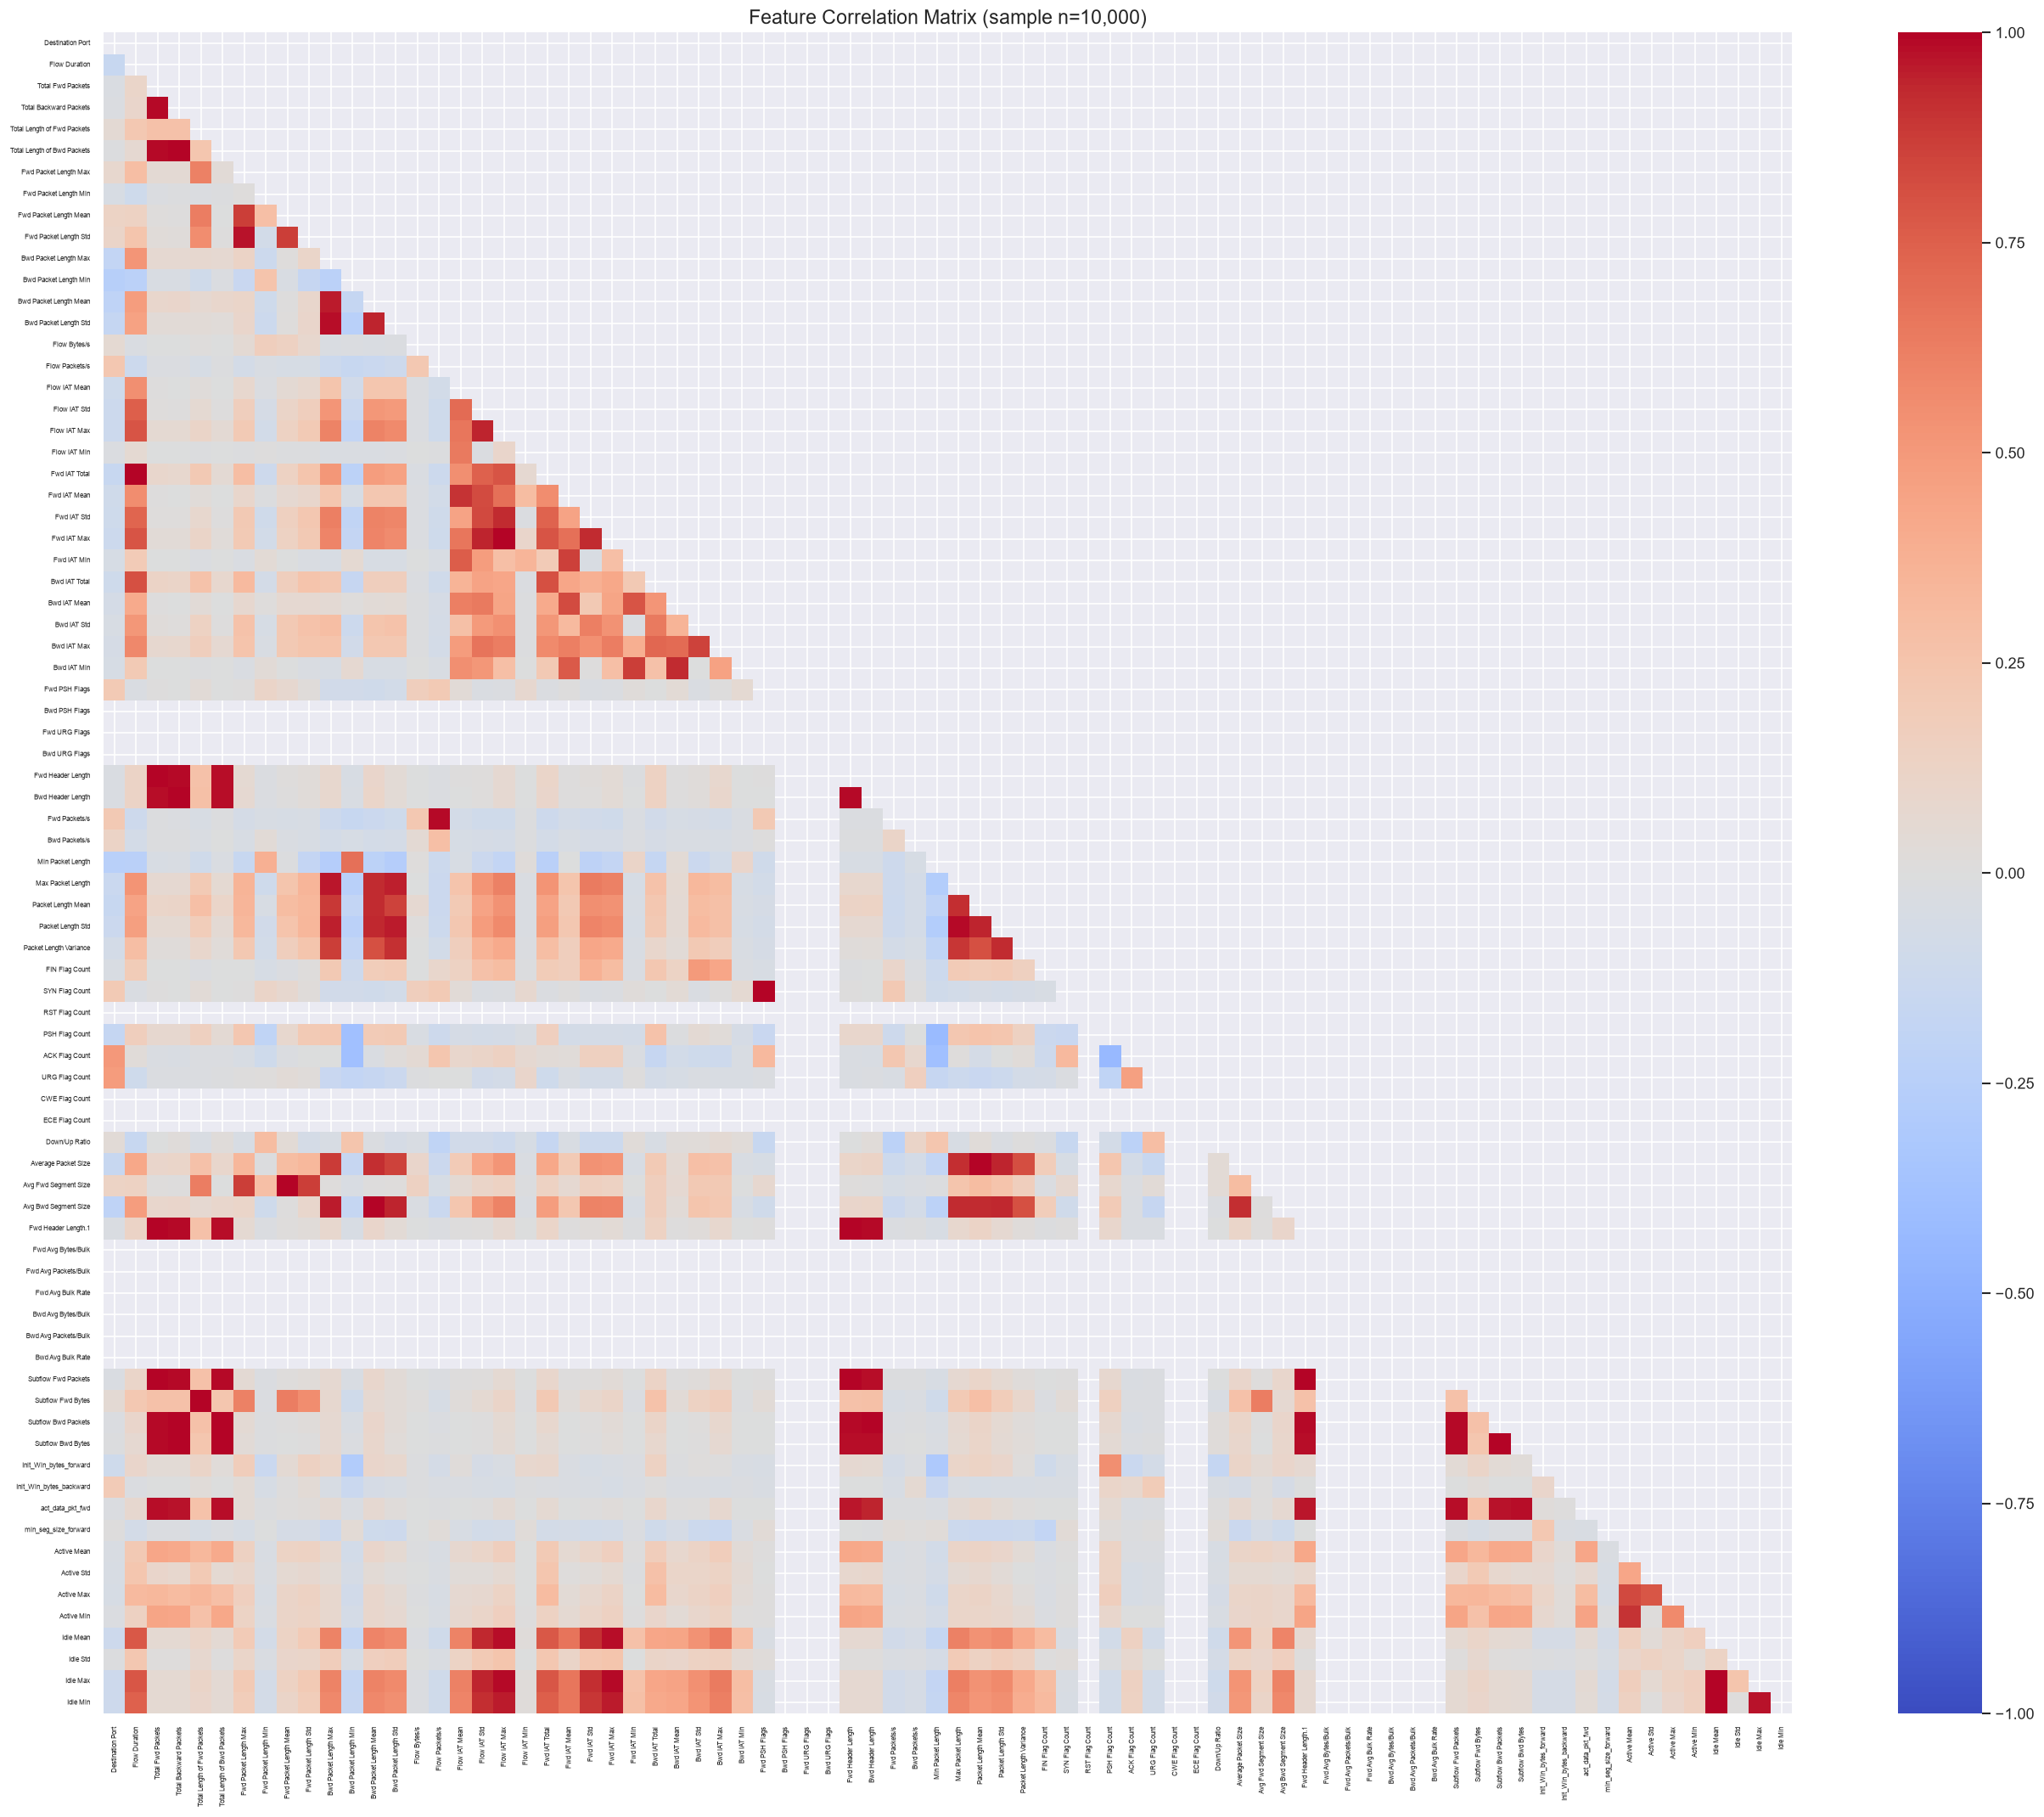

In [17]:
# Plot full correlation heatmap - small figure since 78 features is dense
fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=False,
            xticklabels=True, yticklabels=True,
            linewidths=0, ax=ax)
ax.set_title('Feature Correlation Matrix (sample n=10,000)', fontsize=14)
ax.tick_params(axis='x', labelsize=5, rotation=90)
ax.tick_params(axis='y', labelsize=5)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 9. Feature Distributions by Attack Type (Key Features)

In [18]:
# Key features from the CICIDS2017 paper (Table 3) that exist in this dataset
key_features = [
    ' Flow Duration', ' Flow IAT Mean', ' Flow IAT Min',
    ' Bwd Packet Length Std', ' Init_Win_bytes_forward',
    ' Subflow Fwd Bytes', ' PSH Flag Count', ' ACK Flag Count'
]

# Filter to only features that exist
key_features = [f for f in key_features if f in df.columns]
print(f'Plotting distributions for: {key_features}')

sample_dist = df[key_features + ['Attack Type']].dropna().sample(min(20000, len(df)), random_state=42)

Plotting distributions for: []


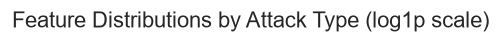

In [19]:
n_features = len(key_features)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for attack_type in sample_dist['Attack Type'].unique():
        subset = sample_dist[sample_dist['Attack Type'] == attack_type][feat]
        # log scale for better visibility
        subset_pos = subset[subset > 0]
        if len(subset_pos) > 0:
            axes[i].hist(np.log1p(subset_pos), bins=50, alpha=0.4, label=attack_type, density=True)
    axes[i].set_title(feat.strip(), fontsize=9)
    axes[i].set_xlabel('log1p(value)')
    axes[i].set_ylabel('Density')
    if i == 0:
        axes[i].legend(fontsize=6)

# Hide unused subplots
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Attack Type (log1p scale)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions_by_class.png', bbox_inches='tight')
plt.show()

## 10. Per-Class Feature Statistics (Mean)

In [20]:
per_class_means = df.groupby('Attack Type')[numeric_cols].mean().T
per_class_means.to_csv('per_class_feature_means.csv')
print('Saved: per_class_feature_means.csv')
per_class_means.head(20)

Saved: per_class_feature_means.csv


Attack Type,Brute Force,DDoS,DoS,Normal Traffic,Port Scan
Destination Port,2.143050e+01,8.122738e+01,8.000000e+01,9.419545e+03,8624.460177
Flow Duration,5.218976e+06,1.695559e+07,5.570027e+07,1.122082e+07,82820.228371
Total Fwd Packets,7.895844e+00,4.472439e+00,5.339423e+00,1.065417e+01,1.017580
Total Backward Packets,1.152685e+01,3.255821e+00,4.056609e+00,1.213864e+01,1.004958
Total Length of Fwd Packets,4.643437e+02,3.190860e+01,3.037442e+02,6.355369e+02,1.089171
Total Length of Bwd Packets,6.431754e+02,7.373635e+03,7.377115e+03,1.884871e+04,12.237866
Fwd Packet Length Max,1.479978e+02,1.489764e+01,2.329700e+02,2.303862e+02,1.069760
Fwd Packet Length Min,1.460065e-02,2.185039e+00,2.851778e+00,2.279337e+01,0.987391
Fwd Packet Length Mean,2.579422e+01,7.401262e+00,4.788973e+01,6.639606e+01,1.009443
Fwd Packet Length Std,3.558823e+01,5.721986e+00,9.525939e+01,7.455631e+01,0.041034


## 11. Duplicate Row Check

In [21]:
dup_count = df.duplicated(subset=numeric_cols).sum()
print(f'Duplicate rows (on numeric features): {dup_count:,}')
print(f'As percentage: {100*dup_count/len(df):.2f}%')

Duplicate rows (on numeric features): 309,029
As percentage: 10.93%


## 12. Summary: What to Drop Before Training

In [22]:
print('=== PREPROCESSING RECOMMENDATIONS ===')
print(f'1. Constant columns to drop: {constant_cols}')
print(f'2. High-corr pairs (>= 0.99): {len(high_corr_pairs)} pairs found — drop one from each')
print(f'3. Missing/inf rows: {df[numeric_cols].isna().any(axis=1).sum():,} rows affected')
print(f'4. Duplicate rows: {dup_count:,}')
print(f'5. Infiltration and Heartbleed already removed.')
print(f'\nFinal dataset shape after label grouping: {df.shape}')
print(f'\nClass counts:')
print(df['Attack Type'].value_counts())

=== PREPROCESSING RECOMMENDATIONS ===
1. Constant columns to drop: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
2. High-corr pairs (>= 0.99): 27 pairs found — drop one from each
3. Missing/inf rows: 2,857 rows affected
4. Duplicate rows: 309,029
5. Infiltration and Heartbleed already removed.

Final dataset shape after label grouping: (2826550, 81)

Class counts:
Attack Type
Normal Traffic    2273097
DoS                252661
Port Scan          158930
DDoS               128027
Brute Force         13835
Name: count, dtype: int64


In [23]:
for a, b, v in high_corr_pairs:
    print(f'{a:40s} <--> {b:40s} : {v:.4f}')

Flow Duration                            <--> Fwd IAT Total                            : 0.9981
Total Fwd Packets                        <--> Total Backward Packets                   : 0.9909
Total Fwd Packets                        <--> Fwd Header Length                        : 0.9956
Total Fwd Packets                        <--> Fwd Header Length.1                      : 0.9956
Total Fwd Packets                        <--> Subflow Fwd Packets                      : 1.0000
Total Fwd Packets                        <--> Subflow Bwd Packets                      : 0.9909
Total Backward Packets                   <--> Total Length of Bwd Packets              : 0.9948
Total Backward Packets                   <--> Bwd Header Length                        : 0.9931
Total Backward Packets                   <--> Subflow Fwd Packets                      : 0.9909
Total Backward Packets                   <--> Subflow Bwd Packets                      : 1.0000
Total Backward Packets                  

In [25]:
label_map = {
    'BENIGN': 'Normal Traffic',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'DDoS': 'DDoS',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'PortScan': 'Port Scan'
}

df['Attack Type'] = df['Label'].map(label_map)
df_clean = df.dropna(subset=['Attack Type']).copy()
print(df_clean['Attack Type'].value_counts())
print(f'\nShape: {df_clean.shape}')

Attack Type
Normal Traffic    2273097
DoS                252661
Port Scan          158930
DDoS               128027
Brute Force         13835
Name: count, dtype: int64

Shape: (2826550, 81)


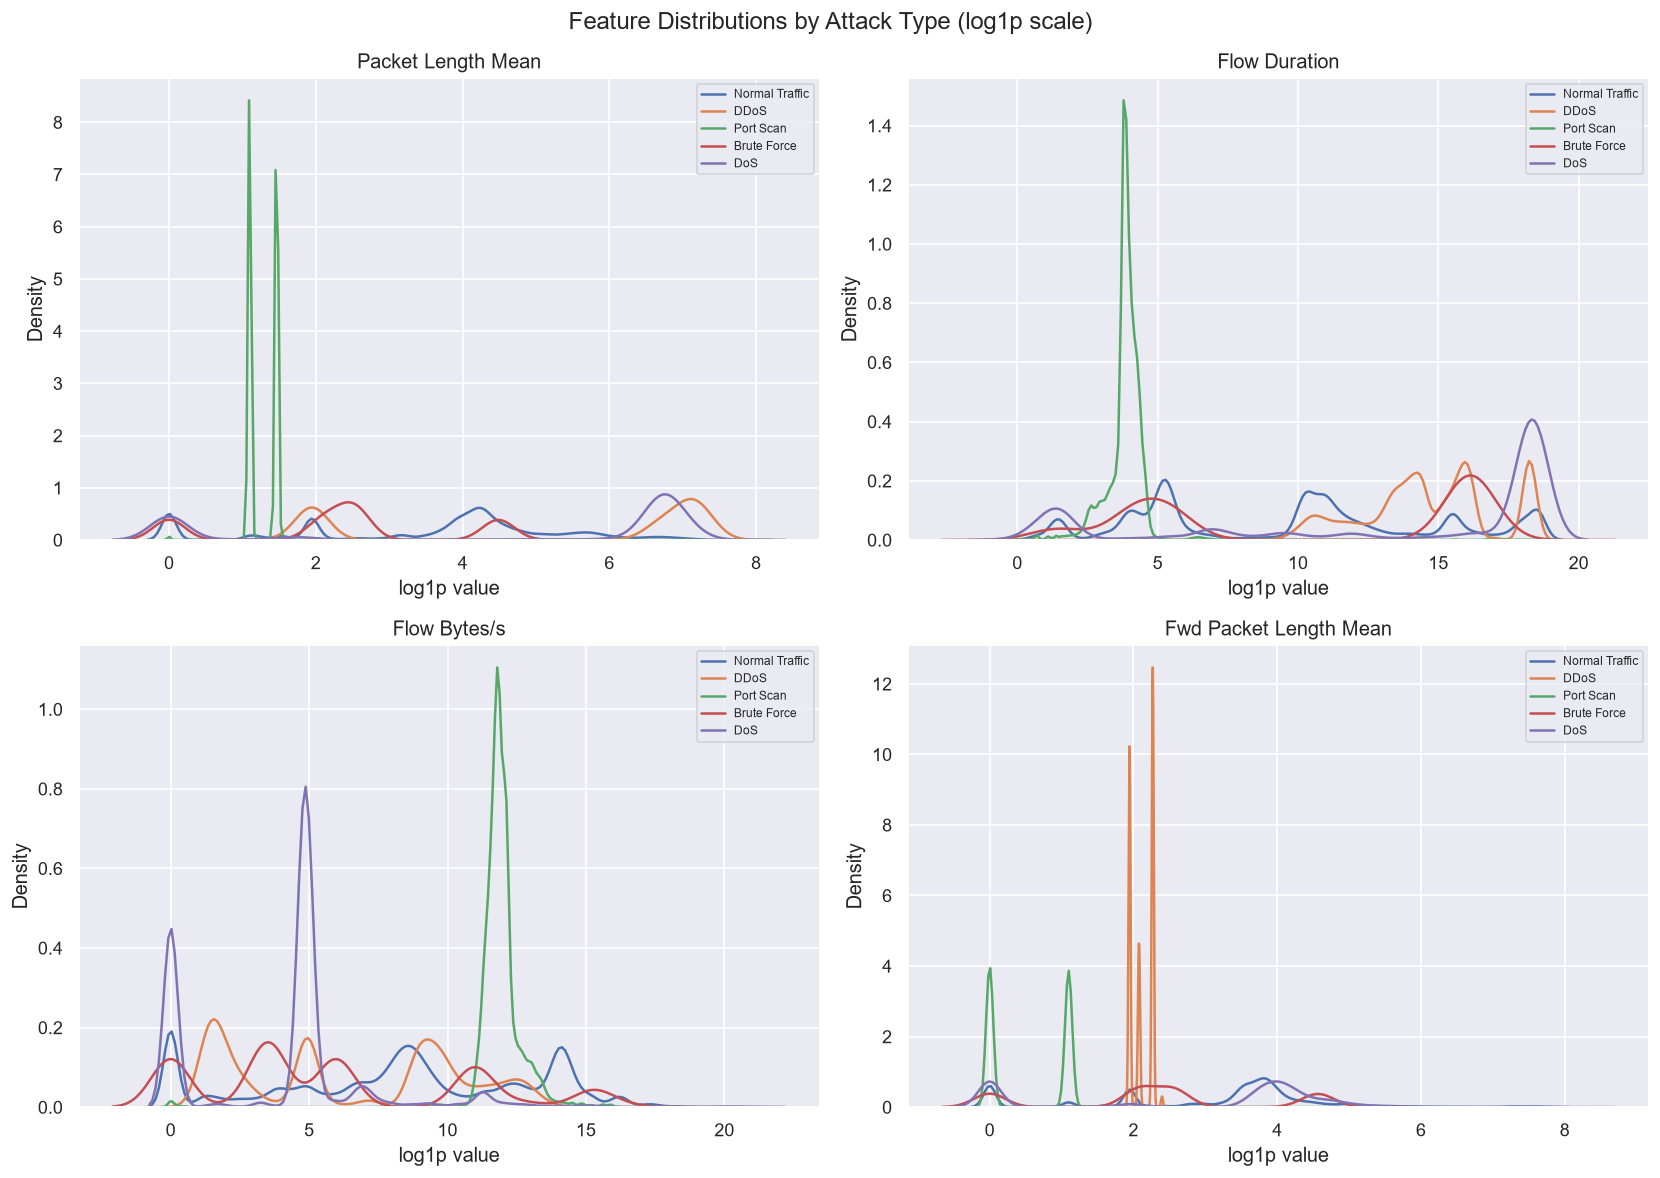

In [26]:
features = ['Packet Length Mean', 'Flow Duration', 'Flow Bytes/s', 'Fwd Packet Length Mean']
classes = df_clean['Attack Type'].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions by Attack Type (log1p scale)')

for ax, feat in zip(axes.flatten(), features):
    for cls in classes:
        subset = df_clean[df_clean['Attack Type'] == cls][feat].dropna()
        subset = np.log1p(subset.clip(lower=0))
        sns.kdeplot(subset, ax=ax, label=cls, fill=False)
    ax.set_title(feat)
    ax.set_xlabel('log1p value')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('feature_distributions_by_class.png', dpi=150)
plt.show()

In [27]:
means = df_clean.groupby('Attack Type')[features].mean()
print(means.to_string())

                Packet Length Mean  Flow Duration  Flow Bytes/s  Fwd Packet Length Mean
Attack Type                                                                            
Brute Force              24.516778   5.218976e+06  4.588162e+05               25.794217
DDoS                    736.885283   1.695559e+07  6.111788e+04                7.401262
DoS                     565.661702   5.570027e+07  5.007285e+05               47.889731
Normal Traffic          109.292840   1.122082e+07  1.779842e+06               66.396064
Port Scan                 3.246025   8.282023e+04  2.203598e+05                1.009443


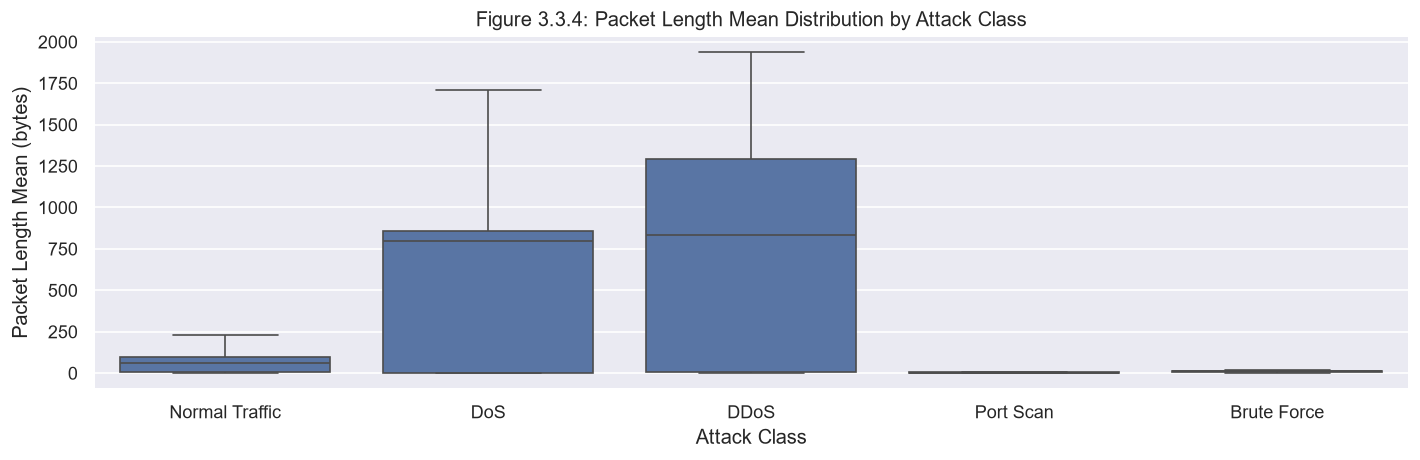

In [28]:
# Figure 3.3.4: Packet Length Mean Distribution by Attack Class
plt.figure(figsize=(12, 4))
sns.boxplot(data=df_clean, x='Attack Type', y='Packet Length Mean',
            order=['Normal Traffic', 'DoS', 'DDoS', 'Port Scan', 'Brute Force'],
            showfliers=False)
plt.title('Figure 3.3.4: Packet Length Mean Distribution by Attack Class')
plt.xlabel('Attack Class')
plt.ylabel('Packet Length Mean (bytes)')
plt.tight_layout()
plt.savefig('packet_length_mean_boxplot.png', dpi=150)
plt.show()

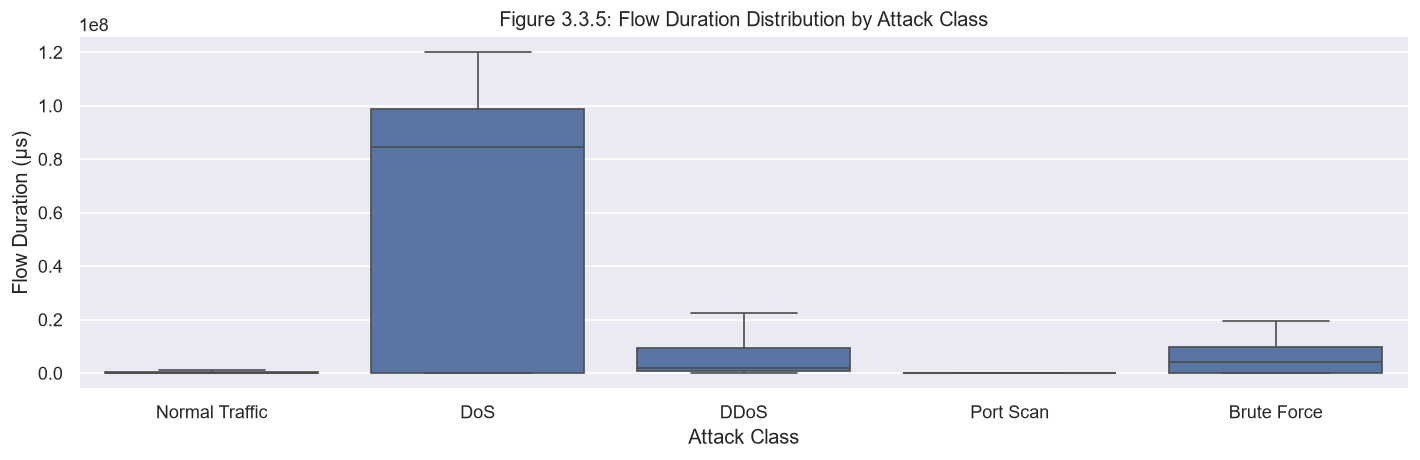

In [29]:
# Figure 3.3.5: Flow Duration Distribution by Attack Class
plt.figure(figsize=(12, 4))
sns.boxplot(data=df_clean, x='Attack Type', y='Flow Duration',
            order=['Normal Traffic', 'DoS', 'DDoS', 'Port Scan', 'Brute Force'],
            showfliers=False)
plt.title('Figure 3.3.5: Flow Duration Distribution by Attack Class')
plt.xlabel('Attack Class')
plt.ylabel('Flow Duration (µs)')
plt.tight_layout()
plt.savefig('flow_duration_boxplot.png', dpi=150)
plt.show()